## Autoencoder Implementation with Fashion MNIST



In [23]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

### 1. Load and Preprocess the Dataset



In [24]:
# Load the Fashion MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape the images to be flat vectors (784 dimensions) for the autoencoder input
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

x_train shape: (60000, 784)
x_test shape: (10000, 784)


### 2. Build the Autoencoder Model

An autoencoder consists of two main parts:
*   **Encoder:** Compresses the input data into a lower-dimensional latent-space representation.
*   **Decoder:** Reconstructs the input data from the latent-space representation.

We'll use a simple fully-connected (dense) neural network for both the encoder and decoder.

In [25]:
# Define the dimensions of the input and the latent space
input_dim = x_train.shape[1] # 28 * 28 = 784
latent_dim = 32 # This is the bottleneck layer size, a smaller dimension to learn compressed representation

# Encoder architecture
encoder_input = layers.Input(shape=(input_dim,))
encoded = layers.Dense(128, activation='relu')(encoder_input)
encoded = layers.Dense(latent_dim, activation='relu')(encoded) # Latent space

# Decoder architecture
decoder_input = layers.Input(shape=(latent_dim,))
decoded = layers.Dense(128, activation='relu')(decoder_input)
decoded = layers.Dense(input_dim, activation='sigmoid')(decoded) # Output should be between 0 and 1

# Combine encoder and decoder into a full autoencoder model
encoder = models.Model(encoder_input, encoded, name="encoder")
decoder = models.Model(decoder_input, decoded, name="decoder")

autoencoder_output = decoder(encoder(encoder_input))
autoencoder = models.Model(encoder_input, autoencoder_output, name="autoencoder")

autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 32)             │       104,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 784)            │       105,360 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

### 3. Autoencoder Performance



In [26]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# Load the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape the images to be flat vectors (784 dimensions) for the autoencoder input
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

# Define the dimensions of the input and the latent space
input_dim = x_train.shape[1] # 28 * 28 = 784
latent_dim = 32 # This is the bottleneck layer size, a smaller dimension to learn compressed representation

# Encoder architecture
encoder_input = layers.Input(shape=(input_dim,))
encoded = layers.Dense(128, activation='relu')(encoder_input)
encoded = layers.Dense(latent_dim, activation='relu')(encoded) # Latent space

# Decoder architecture
decoder_input = layers.Input(shape=(latent_dim,))
decoded = layers.Dense(128, activation='relu')(decoder_input)
decoded = layers.Dense(input_dim, activation='sigmoid')(decoded) # Output should be between 0 and 1

# Combine encoder and decoder into a full autoencoder model
encoder = models.Model(encoder_input, encoded, name="encoder")
decoder = models.Model(decoder_input, decoded, name="decoder")

autoencoder_output = decoder(encoder(encoder_input))
autoencoder = models.Model(encoder_input, autoencoder_output, name="autoencoder")

autoencoder.summary()

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train the autoencoder with more epochs for better reconstruction
history = autoencoder.fit(x_train, x_train,
                          epochs=200, # Increased epochs
                          batch_size=256,
                          shuffle=True,
                          validation_data=(x_test, x_test))

x_train shape: (60000, 784)
x_test shape: (10000, 784)


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 32)             │       104,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 784)            │       105,360 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.3718 - val_loss: 0.3149
Epoch 2/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3048 - val_loss: 0.3019
Epoch 3/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2968 - val_loss: 0.2962
Epoch 4/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2918 - val_loss: 0.2920
Epoch 5/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2884 - val_loss: 0.2891
Epoch 6/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2859 - val_loss: 0.2870
Epoch 7/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2841 - val_loss: 0.2856
Epoch 8/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2827 - val_loss: 0.2842
Epoch 9/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2818 - val_loss: 0.2841
Epoch 10/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2805 - val_loss: 0.2824
Epoch 11/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2797 - val_loss: 0.2816
Epoch 12/200
235/235 ━━━━━━━━━━━━━━━━━━━━

### 4. Visualize Reconstruction Results

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


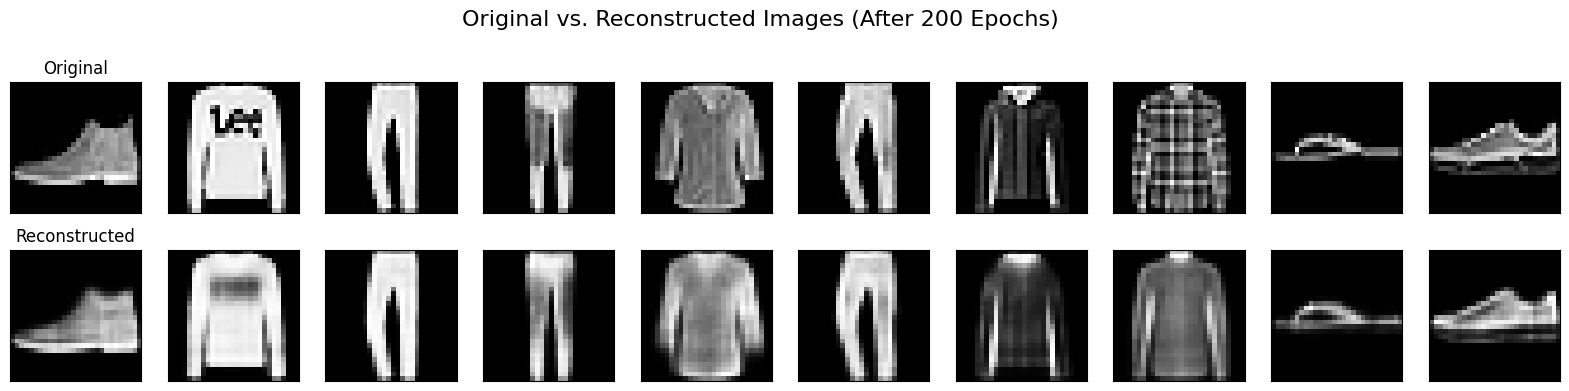

In [27]:
# Use the autoencoder to predict reconstructions on the test set
reconstructed_images = autoencoder.predict(x_test)

# Number of images to display
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0: ax.set_title('Original')

    # Display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_images[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0: ax.set_title('Reconstructed')
plt.suptitle('Original vs. Reconstructed Images (After 200 Epochs)', y=1.05, fontsize=16)
plt.show()